In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/linyingyu/ai-human-csv/AI_Human.csv
/kaggle/input/datasets/linyingyu/glove-6b-300d-txt/glove.6B.300d.txt


In [2]:
from pathlib import Path
import re

import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm


def clean_text(raw_text: str) -> str:
    if not isinstance(raw_text, str):
        return ""

    cleaned_text = raw_text.strip()
    cleaned_text = re.sub(r"\s+", " ", cleaned_text)
    cleaned_text = cleaned_text.replace("\x00", "")

    return cleaned_text


def load_large_csv(csv_path: str, chunk_size: int = 50000) -> pd.DataFrame:
    processed_chunks = []
    total_rows_processed = 0

    print("Starting to load dataset in chunks...\n")

    chunk_iterator = pd.read_csv(
        csv_path,
        usecols=["text", "generated"],
        chunksize=chunk_size,
    )

    for chunk_index, chunk_dataframe in enumerate(tqdm(chunk_iterator, desc="Processing chunks")):
        original_size = len(chunk_dataframe)

        chunk_dataframe = chunk_dataframe.dropna(subset=["text", "generated"]).copy()

        chunk_dataframe["text"] = chunk_dataframe["text"].astype(str).map(clean_text)
        chunk_dataframe["generated"] = pd.to_numeric(
            chunk_dataframe["generated"],
            errors="coerce",
        )

        chunk_dataframe = chunk_dataframe.dropna(subset=["generated"])
        chunk_dataframe["generated"] = chunk_dataframe["generated"].astype(int)

        chunk_dataframe = chunk_dataframe[
            chunk_dataframe["generated"].isin([0, 1])
        ].copy()

        chunk_dataframe = chunk_dataframe[
            chunk_dataframe["text"].str.len() > 0
        ].copy()

        processed_size = len(chunk_dataframe)
        total_rows_processed += processed_size

        print(
            f"Chunk {chunk_index + 1}: "
            f"{original_size} → {processed_size} rows | "
            f"Total processed: {total_rows_processed}"
        )

        processed_chunks.append(chunk_dataframe)

    print(f"\nFinished loading all chunks. Total rows: {total_rows_processed}")

    full_dataframe = pd.concat(processed_chunks, ignore_index=True)
    return full_dataframe


def preprocess_dataset(
    input_csv_path: str,
    output_directory: str = "dataset/processed_data",
    sample_size: int | None = None,
) -> None:
    output_path = Path(output_directory)
    output_path.mkdir(parents=True, exist_ok=True)

    dataframe = load_large_csv(input_csv_path)

    print("\nFinished loading dataset.")
    print(f"Rows before duplicate removal: {len(dataframe)}")

    dataframe = dataframe.drop_duplicates(subset=["text"]).reset_index(drop=True)

    print(f"Rows after duplicate removal: {len(dataframe)}")
    print("\nClass distribution:")
    print(dataframe["generated"].value_counts())

    if sample_size is not None and sample_size < len(dataframe):
        dataframe = dataframe.groupby("generated", group_keys=False).apply(
            lambda group: group.sample(
                n=min(len(group), sample_size // 2),
                random_state=42,
            )
        ).reset_index(drop=True)

        print(f"\nApplied balanced sampling. New size: {len(dataframe)}")
        print(dataframe["generated"].value_counts())

    print("\nSplitting dataset...")

    train_dataframe, temp_dataframe = train_test_split(
        dataframe,
        test_size=0.2,
        random_state=42,
        stratify=dataframe["generated"],
    )

    validation_dataframe, test_dataframe = train_test_split(
        temp_dataframe,
        test_size=0.5,
        random_state=42,
        stratify=temp_dataframe["generated"],
    )

    print("Saving files...")

    train_output_path = output_path / "train.csv"
    validation_output_path = output_path / "validation.csv"
    test_output_path = output_path / "test.csv"
    full_output_path = output_path / "full_cleaned.csv"

    dataframe.to_csv(full_output_path, index=False)
    train_dataframe.to_csv(train_output_path, index=False)
    validation_dataframe.to_csv(validation_output_path, index=False)
    test_dataframe.to_csv(test_output_path, index=False)

    print("\nDone ")
    print(f"- Full cleaned dataset: {full_output_path}")
    print(f"- Train set: {train_output_path}")
    print(f"- Validation set: {validation_output_path}")
    print(f"- Test set: {test_output_path}")


def create_subset_splits(
    dataframe: pd.DataFrame,
    subset_size: int,
    output_directory: str,
) -> None:
    print(f"\n=== Creating dataset with size: {subset_size} ===")

    # Ensure balanced sampling
    samples_per_class = subset_size // 2

    subset_dataframe = dataframe.groupby("generated", group_keys=False).apply(
        lambda group: group.sample(
            n=min(len(group), samples_per_class),
            random_state=42,
        )
    ).reset_index(drop=True)

    print("Subset class distribution:")
    print(subset_dataframe["generated"].value_counts())

    # Split: 80 train, 10 val, 10 test
    train_df, temp_df = train_test_split(
        subset_dataframe,
        test_size=0.2,
        random_state=42,
        stratify=subset_dataframe["generated"],
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=42,
        stratify=temp_df["generated"],
    )

    # Create directory
    output_path = Path(output_directory)
    output_path.mkdir(parents=True, exist_ok=True)

    # Save files
    train_df.to_csv(output_path / "train.csv", index=False)
    val_df.to_csv(output_path / "validation.csv", index=False)
    test_df.to_csv(output_path / "test.csv", index=False)

    print(f"Saved to {output_directory}")


if __name__ == "__main__":
    full_dataframe = load_large_csv("/kaggle/input/datasets/linyingyu/ai-human-csv/AI_Human.csv")

    print("\nRemoving duplicates...")
    full_dataframe = full_dataframe.drop_duplicates(subset=["text"]).reset_index(drop=True)

    print("\nFinal dataset distribution:")
    print(full_dataframe["generated"].value_counts())

    # Create multiple dataset sizes
    create_subset_splits(full_dataframe, 5000, "processed_data/dataset_5k")
    create_subset_splits(full_dataframe, 20000, "processed_data/dataset_20k")
    create_subset_splits(full_dataframe, 100000, "processed_data/dataset_100k")

Starting to load dataset in chunks...



Processing chunks: 1it [00:08,  8.51s/it]

Chunk 1: 50000 → 50000 rows | Total processed: 50000


Processing chunks: 2it [00:17,  8.61s/it]

Chunk 2: 50000 → 49996 rows | Total processed: 99996


...

Saved to processed_data/dataset_5k

=== Creating dataset with size: 20000 ===
Subset class distribution:
generated
0    10000
1    10000
Name: count, dtype: int64


/tmp/ipykernel_55/3119477805.py:146: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset_dataframe = dataframe.groupby("generated", group_keys=False).apply(


Saved to processed_data/dataset_20k

=== Creating dataset with size: 100000 ===
Subset class distribution:
generated
0    50000
1    50000
Name: count, dtype: int64


/tmp/ipykernel_55/3119477805.py:146: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset_dataframe = dataframe.groupby("generated", group_keys=False).apply(


Saved to processed_data/dataset_100k


[INFO] 使用设备: cuda
[Tokenizer] 词表大小: 50000
[INFO] 验证集: 2000 | 测试集: 2000
[GloVe] 正在加载 /kaggle/input/datasets/linyingyu/glove-6b-300d-txt/glove.6B.300d.txt ...
[GloVe] 命中词数: 23455 / 50000

====== Learning Curve 实验 ======

[LC] 训练集大小: 5000（实际: 4000 条）
  Epoch 01/5 | Loss: 0.6141 | Val Acc: 0.8145 | Val Macro-F1: 0.8132 | Precision: 0.8237 | Recall: 0.8145 | 8.4s
  Epoch 02/5 | Loss: 0.3783 | Val Acc: 0.8735 | Val Macro-F1: 0.8722 | Precision: 0.8892 | Recall: 0.8735 | 7.8s
  Epoch 03/5 | Loss: 0.1987 | Val Acc: 0.8670 | Val Macro-F1: 0.8657 | Precision: 0.8820 | Recall: 0.8670 | 7.9s
  Epoch 04/5 | Loss: 0.1546 | Val Acc: 0.9405 | Val Macro-F1: 0.9405 | Precision: 0.9405 | Recall: 0.9405 | 8.0s
  Epoch 05/5 | Loss: 0.0908 | Val Acc: 0.9505 | Val Macro-F1: 0.9505 | Precision: 0.9511 | Recall: 0.9505 | 8.2s
[BiLSTM] 最佳 Val Macro-F1: 0.9505
  → Acc=0.9505 | Macro-F1=0.9505 | Precision=0.9511 | Recall=0.9505 | 时间=43.6s

[LC] 训练集大小: 20000（实际: 16000 条）
  Epoch 01/5 | Loss: 0.3104 | Val Acc: 0.94

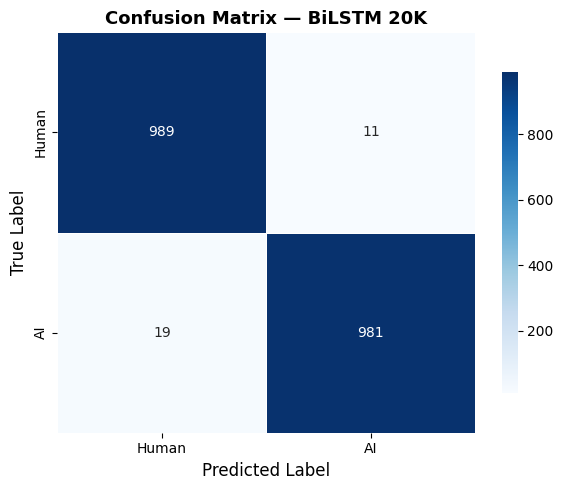

[INFO] 混淆矩阵已保存至 /kaggle/working/outputs/confusion_matrix_BiLSTM_20K.png
  True Negative  (Human→Human): 989
  False Positive (Human→AI):    11
  False Negative (AI→Human):    19
  True Positive  (AI→AI):       981

====== BiLSTM 全量训练（100K） ======
  Epoch 01/10 | Loss: 0.1245 | Val Acc: 0.9960 | Val Macro-F1: 0.9960 | Precision: 0.9960 | Recall: 0.9960 | 163.5s
  Epoch 02/10 | Loss: 0.0230 | Val Acc: 0.9960 | Val Macro-F1: 0.9960 | Precision: 0.9960 | Recall: 0.9960 | 163.4s
  Epoch 03/10 | Loss: 0.0101 | Val Acc: 0.9990 | Val Macro-F1: 0.9990 | Precision: 0.9990 | Recall: 0.9990 | 162.7s
  Epoch 04/10 | Loss: 0.0053 | Val Acc: 0.9975 | Val Macro-F1: 0.9975 | Precision: 0.9975 | Recall: 0.9975 | 162.8s
  Epoch 05/10 | Loss: 0.0038 | Val Acc: 0.9970 | Val Macro-F1: 0.9970 | Precision: 0.9970 | Recall: 0.9970 | 162.9s
  Epoch 06/10 | Loss: 0.0027 | Val Acc: 0.9980 | Val Macro-F1: 0.9980 | Precision: 0.9980 | Recall: 0.9980 | 163.0s
  Epoch 07/10 | Loss: 0.0025 | Val Acc: 0.9970 | Val Macr

In [3]:
"""
Member B: Sequence Modeler & Efficiency Analyst
任务：BiLSTM (GloVe) 模型训练、Learning Curve 实验、性能指标追踪
"""

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    precision_score, recall_score, confusion_matrix,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] 使用设备: {DEVICE}")


# ─────────────────────────────────────────────
# 1. 文本 → 词索引 (Tokenizer)
# ─────────────────────────────────────────────
class SimpleTokenizer:
    """基于词频的简单分词器，配合 GloVe 使用"""

    def __init__(self, max_vocab: int = 50_000, max_len: int = 256):
        self.max_vocab = max_vocab
        self.max_len   = max_len
        self.word2idx  = {'<PAD>': 0, '<UNK>': 1}
        self.fitted    = False

    def fit(self, texts):
        from collections import Counter
        counter = Counter()
        for t in texts:
            counter.update(t.lower().split())
        for word, _ in counter.most_common(self.max_vocab - 2):
            self.word2idx[word] = len(self.word2idx)
        self.fitted = True
        print(f"[Tokenizer] 词表大小: {len(self.word2idx)}")
        return self

    def encode(self, text: str) -> list:
        tokens = text.lower().split()[:self.max_len]
        ids = [self.word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
        # 补齐 / 截断至 max_len
        ids += [0] * (self.max_len - len(ids))
        return ids

    def encode_batch(self, texts) -> np.ndarray:
        return np.array([self.encode(t) for t in texts], dtype=np.int64)


# ─────────────────────────────────────────────
# 2. 加载 GloVe 预训练词向量
# ─────────────────────────────────────────────
def load_glove(glove_path: str, word2idx: dict, embed_dim: int = 300) -> np.ndarray:
    """
    从 GloVe 文件构建嵌入矩阵
    glove_path: 例如 'glove.6B.300d.txt'
    """
    vocab_size = len(word2idx)
    embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)

    print(f"[GloVe] 正在加载 {glove_path} ...")
    loaded = 0
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word  = parts[0]
            if word in word2idx:
                vec = np.array(parts[1:], dtype=np.float32)
                embedding_matrix[word2idx[word]] = vec
                loaded += 1

    print(f"[GloVe] 命中词数: {loaded} / {vocab_size}")
    return embedding_matrix


# ─────────────────────────────────────────────
# 3. Dataset & DataLoader
# ─────────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.X = torch.tensor(sequences, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(sequences, labels, batch_size=64, shuffle=True):
    ds = TextDataset(sequences, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)


# ─────────────────────────────────────────────
# 4. BiLSTM 模型
# ─────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    """
    双向 LSTM 文本分类器（使用预训练 GloVe 词向量）
    架构：Embedding → BiLSTM → Dropout → FC → 二分类
    """

    def __init__(
        self,
        vocab_size:     int,
        embed_dim:      int   = 300,
        hidden_dim:     int   = 256,
        num_layers:     int   = 2,
        num_classes:    int   = 2,
        dropout:        float = 0.3,
        embedding_matrix: np.ndarray = None,
        freeze_embed:   bool  = False,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(
                torch.tensor(embedding_matrix, dtype=torch.float32)
            )
            if freeze_embed:
                self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))           # (B, L, E)
        out, (hn, _) = self.lstm(emb)                   # out: (B, L, 2H)
        # 取最后一层前向 + 后向的 hidden state
        fwd = hn[-2, :, :]                               # (B, H)
        bwd = hn[-1, :, :]                               # (B, H)
        cat = torch.cat([fwd, bwd], dim=1)               # (B, 2H)
        return self.fc(self.dropout(cat))                # (B, num_classes)


# ─────────────────────────────────────────────
# 5. 训练 & 评估函数
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, n_samples = 0.0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        n_samples  += len(y_batch)
    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())
    acc       = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall    = recall_score(all_labels, all_preds, average='macro')
    return acc, f1, precision, recall, all_preds, all_labels


def train_bilstm(
    model, train_loader, val_loader,
    epochs=10, lr=1e-3
):
    """完整训练循环，返回最佳验证集 Macro-F1 和对应模型状态"""
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1, best_state = 0.0, None
    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(1, epochs + 1):
        t0        = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_f1, val_prec, val_rec, _, _ = evaluate(model, val_loader)
        elapsed   = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"  Epoch {epoch:02d}/{epochs} | "
              f"Loss: {train_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f} | "
              f"Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | "
              f"{elapsed:.1f}s")

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    print(f"[BiLSTM] 最佳 Val Macro-F1: {best_f1:.4f}")
    return model, history


# ─────────────────────────────────────────────
# 6. Learning Curve 实验
# ─────────────────────────────────────────────
LEARNING_CURVE_SIZES = [5_000, 20_000, 100_000]

def run_learning_curve(
    all_X_train_seq, all_y_train,
    val_loader,
    embedding_matrix,
    vocab_size,
    epochs: int = 5,
    results_dict: dict = None,
    save_dir: str = ".",
):
    """
    在不同训练集大小（5K / 20K / 100K）上训练 BiLSTM，
    记录 Accuracy、Macro-F1、Precision、Recall 和训练时间
    """
    if results_dict is None:
        results_dict = {}

    trained_models = {}  # 保存每个大小对应的模型

    for size in LEARNING_CURVE_SIZES:
        if size > len(all_y_train):
            print(f"[LC] 跳过 size={size}（样本数不足）")
            continue

        # 固定种子采样，保证复现
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(all_y_train), size, replace=False)
        X_sub = all_X_train_seq[idx]
        y_sub = all_y_train[idx]

        train_loader = make_loader(X_sub, y_sub, batch_size=64)

        model = BiLSTMClassifier(
            vocab_size=vocab_size,
            embedding_matrix=embedding_matrix,
        ).to(DEVICE)

        print(f"\n[LC] 训练集大小: {size}")
        t_start = time.time()
        model, _ = train_bilstm(model, train_loader, val_loader, epochs=epochs)
        training_time = time.time() - t_start

        acc, f1, precision, recall, _, _ = evaluate(model, val_loader)
        results_dict[size] = {
            'accuracy':      acc,
            'macro_f1':      f1,
            'precision':     precision,
            'recall':        recall,
            'training_time': training_time,
        }
        trained_models[size] = model
        print(f"  → Acc={acc:.4f} | Macro-F1={f1:.4f} | "
              f"Precision={precision:.4f} | Recall={recall:.4f} | 时间={training_time:.1f}s")

    return results_dict, trained_models


def plot_learning_curve(results: dict, save_dir: str = "."):
    """绘制 Learning Curve（F1 & 训练时间）"""
    sizes  = sorted(results.keys())
    f1s    = [results[s]['macro_f1']      for s in sizes]
    times  = [results[s]['training_time'] for s in sizes]
    accs   = [results[s]['accuracy']      for s in sizes]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Macro-F1 vs 数据量
    axes[0].plot(sizes, f1s, marker='o', color='#4C72B0')
    axes[0].set_title('Learning Curve — Macro-F1')
    axes[0].set_xlabel('Training Set Size')
    axes[0].set_ylabel('Macro-F1')
    axes[0].set_xscale('log')
    axes[0].set_xticks(sizes)
    axes[0].set_xticklabels([f'{s//1000}K' for s in sizes])

    # Accuracy vs 数据量
    axes[1].plot(sizes, accs, marker='s', color='#55A868')
    axes[1].set_title('Learning Curve — Accuracy')
    axes[1].set_xlabel('Training Set Size')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_xscale('log')
    axes[1].set_xticks(sizes)
    axes[1].set_xticklabels([f'{s//1000}K' for s in sizes])

    # 训练时间 vs 数据量
    axes[2].bar([f'{s//1000}K' for s in sizes], times, color='#C44E52')
    axes[2].set_title('Training Time vs Dataset Size')
    axes[2].set_xlabel('Training Set Size')
    axes[2].set_ylabel('Training Time (s)')

    plt.tight_layout()
    path = f"{save_dir}/learning_curve.png"
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"[INFO] Learning Curve 图表已保存至 {path}")


# ─────────────────────────────────────────────
# 7. 混淆矩阵
# ─────────────────────────────────────────────
@torch.no_grad()
def plot_confusion_matrix(model, loader, title: str = "BiLSTM", save_dir: str = "."):
    """绘制并保存混淆矩阵"""
    model.eval()
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Human', 'AI'],
        yticklabels=['Human', 'AI'],
        ax=ax,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()

    fname = title.replace(" ", "_").replace("(", "").replace(")", "")
    path  = f"{save_dir}/confusion_matrix_{fname}.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"[INFO] 混淆矩阵已保存至 {path}")

    tn, fp, fn, tp = cm.ravel()
    print(f"  True Negative  (Human→Human): {tn}")
    print(f"  False Positive (Human→AI):    {fp}")
    print(f"  False Negative (AI→Human):    {fn}")
    print(f"  True Positive  (AI→AI):       {tp}")


# ─────────────────────────────────────────────
# 8. 汇总性能指标
# ─────────────────────────────────────────────
def summarize_metrics(lc_results: dict, bilstm_test_metrics: dict, save_dir: str = "."):
    """将所有实验指标汇总为 DataFrame 并保存"""
    rows = []
    for size, m in lc_results.items():
        rows.append({
            'Model':         f'BiLSTM ({size//1000}K)',
            'Accuracy':      round(m['accuracy'],      4),
            'Macro-F1':      round(m['macro_f1'],      4),
            'Precision':     round(m['precision'],     4),
            'Recall':        round(m['recall'],        4),
            'Training_Time': round(m['training_time'], 2),
        })
    rows.append({
        'Model':         'BiLSTM (Full — Test Set)',
        'Accuracy':      round(bilstm_test_metrics.get('accuracy',      0), 4),
        'Macro-F1':      round(bilstm_test_metrics.get('macro_f1',      0), 4),
        'Precision':     round(bilstm_test_metrics.get('precision',     0), 4),
        'Recall':        round(bilstm_test_metrics.get('recall',        0), 4),
        'Training_Time': round(bilstm_test_metrics.get('training_time', 0), 2),
    })
    df_metrics = pd.DataFrame(rows)
    path = f"{save_dir}/metrics_summary.csv"
    df_metrics.to_csv(path, index=False)
    print("\n[汇总] 性能指标：")
    print(df_metrics.to_string(index=False))
    print(f"[INFO] 指标已保存至 {path}")
    return df_metrics


# ─────────────────────────────────────────────
# 主程序
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # Kaggle 路径配置
    BASE_DIR   = "/kaggle/working/processed_data"
    GLOVE_PATH = "/kaggle/input/datasets/linyingyu/glove-6b-300d-txt/glove.6B.300d.txt"
    SAVE_DIR   = "/kaggle/working/outputs"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # ---------- 统一的数据加载函数 ----------
    def load_split(path):
        df = pd.read_csv(path)
        X  = df['text'].fillna("").values
        y  = df['generated'].values
        return X, y

    # ---------- 用 20K 的 val/test 作为统一评估集 ----------
    X_val_raw,  y_val  = load_split(f"{BASE_DIR}/dataset_20k/validation.csv")
    X_test_raw, y_test = load_split(f"{BASE_DIR}/dataset_20k/test.csv")

    # ---------- 用 100K 训练集构建词表（覆盖最广） ----------
    X_vocab_raw, _ = load_split(f"{BASE_DIR}/dataset_100k/train.csv")
    tokenizer = SimpleTokenizer(max_vocab=50_000, max_len=256)
    tokenizer.fit(X_vocab_raw)

    X_val_seq  = tokenizer.encode_batch(X_val_raw)
    X_test_seq = tokenizer.encode_batch(X_test_raw)

    val_loader  = make_loader(X_val_seq,  y_val,  batch_size=128, shuffle=False)
    test_loader = make_loader(X_test_seq, y_test, batch_size=128, shuffle=False)

    print(f"[INFO] 验证集: {len(y_val)} | 测试集: {len(y_test)}")

    # ---------- 加载 GloVe ----------
    embedding_matrix = load_glove(GLOVE_PATH, tokenizer.word2idx, embed_dim=300)

    # ---------- Learning Curve 实验 ----------
    print("\n====== Learning Curve 实验 ======")
    lc_results = {}
    lc_models  = {}

    for size, data_dir in [
        (5_000,   f"{BASE_DIR}/dataset_5k"),
        (20_000,  f"{BASE_DIR}/dataset_20k"),
        (100_000, f"{BASE_DIR}/dataset_100k"),
    ]:
        train_path = f"{data_dir}/train.csv"
        if not os.path.exists(train_path):
            print(f"[LC] 跳过 size={size}（文件不存在: {train_path}）")
            continue

        X_lc, y_lc = load_split(train_path)
        print(f"\n[LC] 训练集大小: {size}（实际: {len(y_lc)} 条）")

        lc_loader = make_loader(
            tokenizer.encode_batch(X_lc), y_lc,
            batch_size=64, shuffle=True,
        )

        model = BiLSTMClassifier(
            vocab_size=len(tokenizer.word2idx),
            embedding_matrix=embedding_matrix,
        ).to(DEVICE)

        t_start = time.time()
        model, _ = train_bilstm(model, lc_loader, val_loader, epochs=5)
        training_time = time.time() - t_start

        acc, f1, precision, recall, _, _ = evaluate(model, val_loader)
        lc_results[size] = {
            'accuracy':      acc,
            'macro_f1':      f1,
            'precision':     precision,
            'recall':        recall,
            'training_time': training_time,
        }
        lc_models[size] = model
        print(f"  → Acc={acc:.4f} | Macro-F1={f1:.4f} | "
              f"Precision={precision:.4f} | Recall={recall:.4f} | 时间={training_time:.1f}s")

    plot_learning_curve(lc_results, save_dir=SAVE_DIR)

    # ---------- 20K 混淆矩阵 ----------
    if 20_000 in lc_models:
        print("\n====== 20K 模型混淆矩阵 ======")
        plot_confusion_matrix(lc_models[20_000], test_loader,
                              title="BiLSTM 20K", save_dir=SAVE_DIR)

    # ---------- 全量 BiLSTM（100K 数据，10 epochs） ----------
    print("\n====== BiLSTM 全量训练（100K） ======")
    X_full, y_full = load_split(f"{BASE_DIR}/dataset_100k/train.csv")
    full_loader = make_loader(
        tokenizer.encode_batch(X_full), y_full,
        batch_size=64, shuffle=True,
    )

    bilstm_model = BiLSTMClassifier(
        vocab_size=len(tokenizer.word2idx),
        embedding_matrix=embedding_matrix,
    ).to(DEVICE)

    t_start = time.time()
    bilstm_model, history = train_bilstm(
        bilstm_model, full_loader, val_loader,
        epochs=10, lr=1e-3,
    )
    training_time_full = time.time() - t_start

    # ---------- 测试集最终评估 ----------
    test_acc, test_f1, test_prec, test_rec, test_preds, test_labels = evaluate(
        bilstm_model, test_loader
    )
    print(f"\n[BiLSTM] 测试集 — Accuracy: {test_acc:.4f} | Macro-F1: {test_f1:.4f} | "
          f"Precision: {test_prec:.4f} | Recall: {test_rec:.4f}")
    print(classification_report(test_labels, test_preds, target_names=['Human', 'AI']))

    bilstm_test_metrics = {
        'accuracy':      test_acc,
        'macro_f1':      test_f1,
        'precision':     test_prec,
        'recall':        test_rec,
        'training_time': training_time_full,
    }

    # ---------- 保存指标汇总 ----------
    summarize_metrics(lc_results, bilstm_test_metrics, save_dir=SAVE_DIR)

    # ---------- 保存模型 ----------
    model_path = f"{SAVE_DIR}/bilstm_model.pt"
    torch.save(bilstm_model.state_dict(), model_path)
    print(f"[INFO] BiLSTM 模型已保存至 {model_path}")

    print("\n[完成] Member B 任务全部执行完毕")

In [ ]:
import os

# 1. 强制列出 working 目录下所有文件
print("--- 检查 /kaggle/working 目录 ---")
for root, dirs, files in os.walk('/kaggle/working'):
    for name in files:
        print(os.path.join(root, name))

# 2. 如果上面什么都没打印出来，说明文件真的丢了
# 请重新运行你的 Member A 预处理函数